In [5]:
import pandas as pd
import numpy as np
import pickle
import time
import json
from pathlib import Path
from sklearn.metrics import f1_score, classification_report, hamming_loss, accuracy_score
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.multioutput import ClassifierChain
import mlflow
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 0. SETUP MLflow
# ==========================================
root_path = Path.cwd().parent
import os
from dotenv import load_dotenv
load_dotenv(dotenv_path=root_path / ".env")
tracking_uri = os.getenv("MLFLOW_TRACKING_URI", (root_path / "mlruns").as_uri())
mlflow.set_tracking_uri(tracking_uri)
mlflow.set_experiment("08b_Threshold_Optimization")

# ==========================================
# 1. LOAD DATA
# ==========================================
print("⏳ 1. Memuat Data...")

train_smote = pd.read_csv(root_path / "Data/processed/train_selected_features.csv")
train_ori   = pd.read_csv(root_path / "Data/split/train_data.csv")
test_df     = pd.read_csv(root_path / "Data/split/test_data.csv")

target_cols = ['risk_depression', 'risk_anxiety', 'risk_stress']

selected_features = [col for col in train_smote.columns if col not in target_cols]

X_full_train_smote = train_smote[selected_features]
Y_full_train_smote = train_smote[target_cols].astype(int)

X_full_train_ori = train_ori.reindex(columns=selected_features, fill_value=0)
Y_full_train_ori = train_ori[target_cols].astype(int)

X_test = test_df.reindex(columns=selected_features, fill_value=0)
Y_test = test_df[target_cols].astype(int)

print(f"✓ Fitur terpilih    : {len(selected_features)} fitur (dari MFO)")
print(f"✓ Fitur             : {selected_features}")
print(f"✓ Train SMOTE       : {X_full_train_smote.shape}")
print(f"✓ Train Asli        : {X_full_train_ori.shape}")
print(f"✓ Test              : {X_test.shape}")

# ==========================================
# 2. SPLIT DATA ASLI → TRAIN_SUB + VALIDATION
# ==========================================
print("\n🔀 2. Split Data Asli → Train_sub & Validation (80-20)")

X_train_sub, X_val, Y_train_sub, Y_val = train_test_split(
    X_full_train_ori, Y_full_train_ori,
    test_size=0.2, random_state=42
)

print(f"✓ Train sub (asli) : {X_train_sub.shape}")
print(f"✓ Validation (asli): {X_val.shape}")

print(f"\nDistribusi Validation (asli):")
print(Y_val.mean().round(4))
print(f"\nDistribusi Test:")
print(Y_test.mean().round(4))

# ==========================================
# 3. LOAD TUNED XGBOOST PARAMETERS
# ==========================================
params_path = root_path / "models" / "best_xgb_params.json"
with open(params_path, 'r') as f:
    xgb_params = json.load(f)
print(f"\n🔧 3. Loaded tuned XGBoost params: {xgb_params}")

# ==========================================
# 4. HELPER FUNCTIONS
# ==========================================
def chain_predict_proba(model, X):
    """
    Rekonstruksi manual predict_proba untuk ClassifierChain.
    """
    X_arr      = X.values if hasattr(X, 'values') else X.copy()
    n_samples  = X_arr.shape[0]
    n_targets  = len(model.estimators_)
    all_probas = np.zeros((n_samples, n_targets))

    X_aug = X_arr.copy()
    for i, estimator in enumerate(model.estimators_):
        proba            = estimator.predict_proba(X_aug)[:, 1]
        all_probas[:, i] = proba
        pred_label       = (proba >= 0.5).astype(int).reshape(-1, 1)
        X_aug            = np.hstack([X_aug, pred_label])

    return [np.column_stack([1 - all_probas[:, i], all_probas[:, i]])
            for i in range(n_targets)]


def chain_predict_proba_threshold(model, X, thresholds):
    """
    Rekonstruksi predict_proba dengan threshold optimal.
    """
    X_arr      = X.values if hasattr(X, 'values') else X.copy()
    n_samples  = X_arr.shape[0]
    n_targets  = len(model.estimators_)
    all_probas = np.zeros((n_samples, n_targets))

    X_aug = X_arr.copy()
    for i, estimator in enumerate(model.estimators_):
        proba            = estimator.predict_proba(X_aug)[:, 1]
        all_probas[:, i] = proba
        pred_label       = (proba >= thresholds[i]).astype(int).reshape(-1, 1)
        X_aug            = np.hstack([X_aug, pred_label])

    return [np.column_stack([1 - all_probas[:, i], all_probas[:, i]])
            for i in range(n_targets)]

print("\n✓ Helper functions defined")

with mlflow.start_run(run_name="XGBoost_ClassifierChain_Final_Standardized"):

    # ==========================================
    # 5. TRAINING MODEL UTAMA (SMOTE)
    # ==========================================
    print("\n🔨 4. Training FINAL MODEL di Full Train SMOTE (fresh)...")
    final_train_start = time.time()
    
    base_xgb = XGBClassifier(**xgb_params)
    final_model = ClassifierChain(base_xgb, order='random', random_state=42)
    final_model.fit(X_full_train_smote, Y_full_train_smote)
    
    final_train_time = time.time() - final_train_start
    print(f"✓ Final model selesai dilatih")
    print(f"   Waktu training: {final_train_time:.2f} detik")

    # ==========================================
    # 6. TRAINING MODEL SEMENTARA (Data Asli, untuk kalibrasi threshold)
    # ==========================================
    print("\n🔧 5. Training model sementara di 80% data asli (untuk kalibrasi threshold)...")
    temp_train_start = time.time()

    base_xgb_temp = XGBClassifier(**xgb_params)
    model_for_threshold = ClassifierChain(base_xgb_temp, order='random', random_state=42)
    model_for_threshold.fit(X_train_sub, Y_train_sub)
    
    temp_train_time = time.time() - temp_train_start
    print(f"✓ Model sementara selesai dilatih")
    print(f"   Waktu training: {temp_train_time:.2f} detik")
    print("  (Model ini hanya untuk kalibrasi threshold, akan dibuang setelahnya)")

    # ==========================================
    # 7. CARI THRESHOLD OPTIMAL DI VALIDATION ASLI
    # ==========================================
    print("\n🔍 6. Mencari Threshold Optimal di Validation ASLI...")
    threshold_start = time.time()

    y_val_proba = chain_predict_proba(model_for_threshold, X_val)

    best_thresholds      = []
    validation_f1_scores = {}

    print(f"\n   {'Target':<22} {'Threshold':>10} {'F1 Val':>10}")
    print(f"   {'-'*45}")

    for i, target_name in enumerate(target_cols):
        y_true    = Y_val.iloc[:, i]
        y_prob    = y_val_proba[i][:, 1]
        thresholds = np.arange(0.1, 0.9, 0.01)
        f1_scores  = []

        for t in thresholds:
            y_pred_temp = (y_prob >= t).astype(int)
            f1_scores.append(f1_score(y_true, y_pred_temp, zero_division=0))

        best_idx = np.argmax(f1_scores)
        best_t   = thresholds[best_idx]
        best_f1  = f1_scores[best_idx]

        best_thresholds.append(best_t)
        validation_f1_scores[target_name] = best_f1

        print(f"   {target_name:<22} {best_t:>10.2f} {best_f1:>10.4f}")

        mlflow.log_param(f"threshold_{target_name}", round(best_t, 2))
        mlflow.log_metric(f"validation_f1_{target_name}", best_f1)

    threshold_time = time.time() - threshold_start
    print(f"   Waktu kalibrasi threshold: {threshold_time:.2f} detik")

    # Buang model sementara
    del model_for_threshold, base_xgb_temp
    print("\n✓ Model sementara dibuang")
    print(f"✓ Threshold hasil kalibrasi: {dict(zip(target_cols, [round(t,2) for t in best_thresholds]))}")

    # ==========================================
    # 8. EVALUASI DEFAULT (THRESHOLD 0.5) DI TEST SET
    # ==========================================
    print("\n📊 7. Evaluasi Default (threshold 0.5) di Test Set...")
    y_pred_default = final_model.predict(X_test)
    
    macro_f1_default = f1_score(Y_test, y_pred_default, average='macro', zero_division=0)
    micro_f1_default = f1_score(Y_test, y_pred_default, average='micro', zero_division=0)
    hamming_default  = hamming_loss(Y_test, y_pred_default)
    exact_default    = accuracy_score(Y_test, y_pred_default)

    # ==========================================
    # 9. EVALUASI THRESHOLD OPTIMIZED DI TEST SET
    # ==========================================
    print("\n🏆 8. Evaluasi Final di TEST SET (Threshold Optimized)...")
    print("   (Final model SMOTE + Threshold dari kalibrasi data asli)")

    y_test_proba = chain_predict_proba_threshold(
        final_model, X_test, best_thresholds
    )

    y_test_optimized = np.zeros((len(X_test), len(target_cols)))
    for i in range(len(target_cols)):
        y_prob                 = y_test_proba[i][:, 1]
        y_test_optimized[:, i] = (y_prob >= best_thresholds[i]).astype(int)

    # ==========================================
    # 10. KALKULASI METRIK
    # ==========================================
    print("\n📊 9. Menghitung Metrik Evaluasi...")

    macro_f1    = f1_score(Y_test, y_test_optimized, average='macro',  zero_division=0)
    micro_f1    = f1_score(Y_test, y_test_optimized, average='micro',  zero_division=0)
    hamming     = hamming_loss(Y_test, y_test_optimized)
    exact_match = accuracy_score(Y_test, y_test_optimized)

    per_label_f1_scores = {}
    for i, target_name in enumerate(target_cols):
        f1 = f1_score(Y_test.iloc[:, i], y_test_optimized[:, i], zero_division=0)
        per_label_f1_scores[target_name] = f1

    # ==========================================
    # 11. TAMPILKAN PERBANDINGAN
    # ==========================================
    print("\n" + "="*70)
    print("📊 PERBANDINGAN DEFAULT vs THRESHOLD OPTIMIZED")
    print("="*70)
    print(f"{'Metrik':<25} {'Default (0.5)':>15} {'Optimized':>15} {'Δ':>10}")
    print("-"*70)
    for label, val_def, val_opt in [
        ("Macro_F1",     macro_f1_default, macro_f1),
        ("Micro_F1",     micro_f1_default, micro_f1),
        ("Hamming_Loss", hamming_default,  hamming),
        ("Exact_Match",  exact_default,    exact_match),
    ]:
        delta = val_opt - val_def
        arrow = "↑" if delta > 0 else ("↓" if delta < 0 else "→")
        print(f"{label:<25} {val_def:>15.4f} {val_opt:>15.4f} {arrow} {delta:>+.4f}")
    print("="*70)

    print(f"\nPer-Label F1 Scores (Threshold Optimized):")
    for label, f1_val in per_label_f1_scores.items():
        print(f"   → {label}: {f1_val:.4f}")

    print("\n📋 Classification Report (Threshold Optimized):")
    class_report = classification_report(
        Y_test, y_test_optimized,
        target_names=['Depression', 'Anxiety', 'Stress'],
        zero_division=0
    )
    print(class_report)

    # ==========================================
    # 12. SAVE MODEL
    # ==========================================
    model_save_path = root_path / "models" / "multilabel_xgboost_classifier_chain.pkl"
    model_save_path.parent.mkdir(parents=True, exist_ok=True)
    with open(model_save_path, "wb") as f:
        pickle.dump(final_model, f)
    print(f"✓ Model disimpan ke: {model_save_path}")

    threshold_save_path = root_path / "models" / "optimal_thresholds.json"
    with open(threshold_save_path, "w") as f:
        json.dump({
            "thresholds": dict(zip(target_cols, [round(t, 4) for t in best_thresholds])),
            "selected_features": selected_features
        }, f, indent=2)
    print(f"✓ Threshold & fitur disimpan ke: {threshold_save_path}")

    # ==========================================
    # 13. MLflow LOGGING
    # ==========================================
    total_time = final_train_time + temp_train_time + threshold_time
    
    print(f"\n📈 10. Logging ke MLflow...")

    mlflow.log_param("strategy",               "Final Model SMOTE + Threshold Kalibrasi Data Asli")
    mlflow.log_param("model_source",            "Fresh Training (bukan load pkl)")
    mlflow.log_param("val_split_ratio",         0.2)
    mlflow.log_param("num_features",            len(selected_features))
    mlflow.log_param("num_labels",              len(target_cols))
    mlflow.log_param("threshold_search_range",  "0.1-0.9")
    mlflow.log_param("threshold_search_step",   0.01)
    mlflow.log_param("threshold_source",        "Data Asli (tanpa SMOTE)")
    for k, v in xgb_params.items():
        mlflow.log_param(f"xgb_{k}", v)

    mlflow.log_metric("default_macro_f1",           macro_f1_default)
    mlflow.log_metric("default_micro_f1",           micro_f1_default)
    mlflow.log_metric("default_hamming_loss",       hamming_default)
    mlflow.log_metric("default_exact_match",        exact_default)

    mlflow.log_metric("test_macro_f1",              macro_f1)
    mlflow.log_metric("test_micro_f1",              micro_f1)
    mlflow.log_metric("test_hamming_loss",          hamming)
    mlflow.log_metric("test_exact_match_accuracy",  exact_match)
    for label, f1_val in per_label_f1_scores.items():
        mlflow.log_metric(f"test_f1_{label}", f1_val)
    mlflow.log_metric("train_sub_samples",   X_train_sub.shape[0])
    mlflow.log_metric("validation_samples",  X_val.shape[0])
    mlflow.log_metric("test_samples",        X_test.shape[0])

    mlflow.log_metric("final_train_time_seconds", final_train_time)
    mlflow.log_metric("temp_train_time_seconds", temp_train_time)
    mlflow.log_metric("threshold_calibration_time_seconds", threshold_time)
    mlflow.log_metric("total_time_seconds", total_time)

    report_path = "classification_report.txt"
    with open(report_path, "w") as f:
        f.write(class_report)
    mlflow.log_artifact(report_path)

    thresholds_path = "optimal_thresholds.txt"
    with open(thresholds_path, "w") as f:
        f.write("Optimal Thresholds per Label:\n")
        f.write("-" * 40 + "\n")
        for label, threshold in zip(target_cols, best_thresholds):
            f.write(f"{label}: {threshold:.4f}\n")
    mlflow.log_artifact(thresholds_path)

    mlflow.log_artifact(str(model_save_path))
    print("✓ MLflow logging complete")

    # ==========================================
    # 14. SUMMARY
    # ==========================================
    print("\n" + "="*70)
    print("🎉 FINAL MODEL SELESAI")
    print("="*70)
    print(f"Strategy     : Fresh Model SMOTE + Threshold Kalibrasi Data Asli")
    print(f"Parameters   : Tuned (loaded from best_xgb_params.json)")
    print(f"Fitur        : {len(selected_features)} fitur (dari MFO, dinamis)")
    print(f"\nDefault (0.5):")
    print(f"   Macro F1  : {macro_f1_default:.4f}")
    print(f"\nThreshold Optimized:")
    print(f"   Macro F1  : {macro_f1:.4f}")
    print(f"   Micro F1  : {micro_f1:.4f}")
    print(f"   Hamming   : {hamming:.4f}")
    print(f"   Exact Match: {exact_match:.4f}")
    print(f"\nWaktu Komputasi:")
    print(f"   Training Model Utama  : {final_train_time:.2f} detik")
    print(f"   Training Model Temp   : {temp_train_time:.2f} detik")
    print(f"   Kalibrasi Threshold   : {threshold_time:.2f} detik")
    print(f"   Total Waktu Komputasi : {total_time:.2f} detik")
    print(f"\nThresholds   :")
    for label, t in zip(target_cols, best_thresholds):
        print(f"   {label}: {t:.4f}")
    print("="*70)


⏳ 1. Memuat Data...
✓ Fitur terpilih    : 13 fitur (dari MFO)
✓ Fitur             : ['TIPI1', 'TIPI3', 'TIPI4', 'TIPI5', 'TIPI6', 'TIPI8', 'TIPI9', 'TIPI10', 'education', 'gender', 'age', 'race', 'familysize']
✓ Train SMOTE       : (8724, 13)
✓ Train Asli        : (21740, 13)
✓ Test              : (5436, 13)

🔀 2. Split Data Asli → Train_sub & Validation (80-20)
✓ Train sub (asli) : (17392, 13)
✓ Validation (asli): (4348, 13)

Distribusi Validation (asli):
risk_depression    0.7150
risk_anxiety       0.7364
risk_stress        0.6118
dtype: float64

Distribusi Test:
risk_depression    0.7068
risk_anxiety       0.7349
risk_stress        0.6078
dtype: float64

🔧 3. Loaded tuned XGBoost params: {'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.03, 'gamma': 0.2, 'colsample_bytree': 0.6667, 'subsample': 0.7667, 'min_child_weight': 5, 'eval_metric': 'logloss', 'random_state': 42, 'n_jobs': -1}

✓ Helper functions defined

🔨 4. Training FINAL MODEL di Full Train SMOTE (fresh)...
✓ Final

📈 ROC-AUC SCORE EVALUATION (FINAL MODEL)
ROC-AUC risk_depression     : 0.7981
ROC-AUC risk_anxiety        : 0.7922
ROC-AUC risk_stress         : 0.8229
-------------------------------------------------------
Macro Average ROC-AUC     : 0.8044


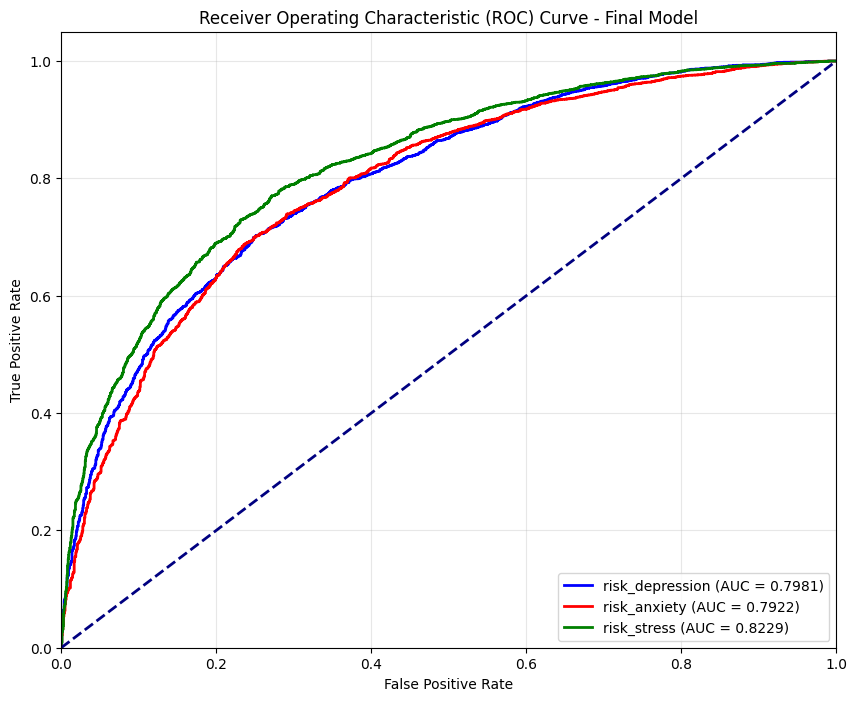

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
import numpy as np

# =============================================
# 15. EVALUASI ROC-AUC
# =============================================
print("=" * 55)
print("📈 ROC-AUC SCORE EVALUATION (FINAL MODEL)")
print("=" * 55)

roc_auc_scores = {}
for i, target_name in enumerate(target_cols):
    y_true = Y_test.iloc[:, i]
    y_prob = y_test_proba[i][:, 1]
    score = roc_auc_score(y_true, y_prob)
    roc_auc_scores[target_name] = score
    print(f"ROC-AUC {target_name:<20}: {score:.4f}")

macro_roc_auc = np.mean(list(roc_auc_scores.values()))
print("-" * 55)
print(f"Macro Average ROC-AUC     : {macro_roc_auc:.4f}")
print("=" * 55)

# Visualisasi Kurva ROC
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green']
for i, target_name in enumerate(target_cols):
    y_true = Y_test.iloc[:, i]
    y_prob = y_test_proba[i][:, 1]
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f"{target_name} (AUC = {roc_auc_scores[target_name]:.4f})")

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Final Model')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()
